# Deflection ΔV Calculator Example Notebook

This notebook calls functions provided in **deflection_propogation.py** to calculate the minimum ΔV (and corresponding time) required to deflect a heliocentric body to some distance away from a main heliocentric body on the Opik B-Plane.

Only a **kinetic** impulse deflection example is shown below.

In the example, "main" corresponds to Earth and "secondary" corresponds to the asteroid.

#### Imports

In [1]:
import numpy as np
from astropy.time import Time
from deflection_propogation import km2au, au2km, au_per_day2km_per_s, grss_sol_to_kepler_elements, get_nominal_sof_and_bplane_grss, solve4accel2perturb_instantaneous_at_time_grss, plot_bplane, plot_bplane_valsecchi, get_states_grss, find_closest_valsecchi_circles

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


/home/wschafer1/projects/AE498PD_FinalProject/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Orbital Elements & Deflection Parameters

In [2]:
t0_mjd = 60522.0  # MJD TDB (2024-07-31) --- impact is confirmed to be 2041-04-24 (~66633 MJD TDB)

elements_main = [
    km2au(147258458.92632198),   # q [AU]
    0.016121536327232226,        # e
    0.4090284044915553,          # i [rad]
    1.8041776521859865,          # w [rad]
    0.0000506875948335585,       # Omega [rad]
    3.5841339494207514           # M [rad]
]

secondary_sol = {
    "t": t0_mjd,
    "e": 0.390657994905,
    "q": 1.00538004981,
    "tp": 60440.5982662,  # MJD TDB
    "om": np.deg2rad(214.423769139),
    "w": np.deg2rad(359.963802784),
    "i": np.deg2rad(10.6888293122),
}

secondary_cov = np.array([
    [ 9.16537871e-13, -1.63466743e-12,  3.89020101e-11,  2.48737127e-12, -2.63252366e-12, -5.36397528e-13],
    [-1.63466743e-12,  3.13128877e-12,  6.19207457e-12, -4.57191920e-12, 6.49897965e-12,  8.38289521e-13],
    [ 3.89020101e-11,  6.19207457e-12,  7.01455580e-08, -3.17541559e-10, 1.48376403e-09, -1.27526089e-10],
    [ 2.48737127e-12, -4.57191920e-12, -3.17541559e-10,  2.28913017e-10, -2.27363461e-10,  2.17832920e-11],
    [-2.63252366e-12,  6.49897965e-12,  1.48376403e-09, -2.27363461e-10, 2.49311599e-10, -2.35745507e-11],
    [-5.36397528e-13,  8.38289521e-13, -1.27526089e-10,  2.17832920e-11, -2.35745507e-11,  5.55074093e-12]
], dtype=float)

mu_sun = 0.0002959112271132008     # AU^3 / day^2
mu_main = 8.8877e-10               # AU^3 / day^2
R_main = 0.0000426354              # AU
R_main_sof = 0.006216666023709612  # AU
secondary_mass = 542.0             # kg

t_max = 30.0 * 365.0
dt_search_imp = 1.0
b_main = 4.0 * R_main

#### Time Entering Sphere of Influence (for time search optimization)

In [3]:
nominal = get_nominal_sof_and_bplane_grss(sol_secondary=secondary_sol, mu_main=mu_main, R_main=R_main, R_sof=R_main_sof, t_max=t_max, dt=1.0)
if nominal is None:
    raise RuntimeError("No nominal SOF crossings found with GRSS propagation.")

print("")
print(f"Found {len(nominal['encounters'])} SOF encounters:\n")
for i, enc in enumerate(nominal["encounters"]):
    t_entry_date = Time(enc["t_entry_abs"], format="mjd", scale="tdb").utc.iso[:10]
    t_ca_date = Time(enc["t_ca_abs"], format="mjd", scale="tdb").utc.iso[:10]
    t_exit_date = Time(enc["t_exit_abs"], format="mjd", scale="tdb").utc.iso[:10]
    print(f"===== ENCOUNTER {i+1} =====")
    print(f"Relative SOF Entry Time: {enc['t_entry_rel']:.6f} d")
    print(f"Absolute SOF Entry Time: {enc['t_entry_abs']:.6f} MJD")
    print(f"SOF Entry Date: {t_entry_date}")
    print(f"Relative Closest Approach Time: {enc['t_ca_rel']:.6f} d")
    print(f"Absolute Closest Approach Time: {enc['t_ca_abs']:.6f} MJD")
    print(f"Closest Approach Date: {t_ca_date}")
    print(f"Relative SOF Exit Time: {enc['t_exit_rel']:.6f} d")
    print(f"Absolute SOF Exit Time: {enc['t_exit_abs']:.6f} MJD")
    print(f"SOF Exit Date: {t_exit_date}")
    print(f"Closest Approach Distance: {enc['d_ca']:.6e} AU")
    print(f"B-Plane Magnitude: {enc['b']:.6e} AU")
    print("")

target_enc = nominal["encounters"][0]
t_sof_target = target_enc["t_entry_rel"]   # latest allowed control time
t_eval_target = target_enc["t_ca_rel"]     # evaluation time for non-GRSS b-plane
elements_secondary_nongrss = grss_sol_to_kepler_elements(secondary_sol, mu_sun)


Found 1 SOF encounters:

===== ENCOUNTER 1 =====
Relative SOF Entry Time: 6110.397072 d
Absolute SOF Entry Time: 66632.397072 MJD
SOF Entry Date: 2041-04-23
Relative Closest Approach Time: 6111.688140 d
Absolute Closest Approach Time: 66633.688140 MJD
Closest Approach Date: 2041-04-24
Relative SOF Exit Time: 6112.977412 d
Absolute SOF Exit Time: 66634.977412 MJD
SOF Exit Date: 2041-04-25
Closest Approach Distance: 7.867834e-06 AU
B-Plane Magnitude: 2.299608e-05 AU



---
## Kinetic Deflection Example

#### Single-Time Minimum ΔV Calculation

Define the time at which to first apply the impulse below.

In [4]:
t_impulse = 2414.0    # test impulse time [d] (relative to t0_mjd) --- corresponds to 2031-03-11 (62936 MJD TDB)

Due to the vast memory requirements of GRSS, each of the following directions must be computed individually below.

**Transverse Direction**

In [5]:
dV_min, b_val, b_case, b_cloud = solve4accel2perturb_instantaneous_at_time_grss(
    sol_secondary=secondary_sol,      # asteroid GRSS solution dict
    cov_secondary=secondary_cov,      # asteroid covariance in GRSS order [e, q, tp, om, w, i]; use None for no covariance
    mu_main=mu_main,                  # Earth gravitational parameter [AU^3 / day^2]
    R_main=R_main,                    # Earth radius [AU]
    R_sof=R_main_sof,                 # sphere-of-influence radius used for encounter definition [AU]
    direction="transverse",               # applied impulse direction
    b_target=b_main,                  # desired minimum b-plane miss distance [AU]
    t_impulse=t_impulse,              # impulse application time [days after epoch]
    t_max=t_max,                      # propagation horizon [days after epoch]
    dt=dt_search_imp,                 # time step used inside SOF/crossing searches [days]
    robust_metric="min_b",            # optimize against worst-case sigma-point b-plane miss distance
)
sign_label = "+" if dV_min >= 0 else "-"
print(f"--- Transverse Impulse ---")
print(f"Sign: {sign_label}")
print(f"Relative Impulse Time: {t_impulse:.6f} d")
print(f"Minimum Required Impulse DeltaV: {au_per_day2km_per_s(abs(dV_min)):.6e} km/s")
print(f"Achieved Robust B-Plane Distance: {b_val:.6e} AU")
print(f"Worst-Case SOF Time: {b_case['t_sof_rel']:.6f} d")
print(f"Worst-Case xi: {b_case['xi']:.6e} AU")
print(f"Worst-Case zeta: {b_case['zeta']:.6e} AU")
print("")


--- Transverse Impulse ---
Sign: +
Relative Impulse Time: 2414.000000 d
Minimum Required Impulse DeltaV: 2.588762e-05 km/s
Achieved Robust B-Plane Distance: 1.705416e-04 AU
Worst-Case SOF Time: 6110.431749 d
Worst-Case xi: 5.841672e-06 AU
Worst-Case zeta: -1.704415e-04 AU



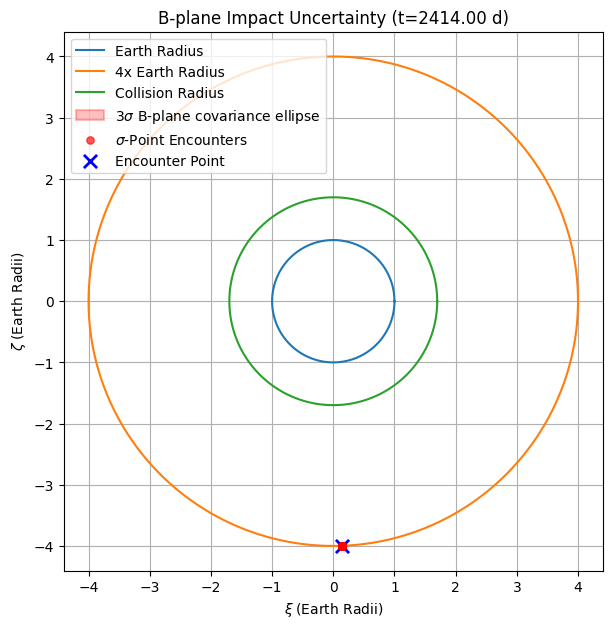

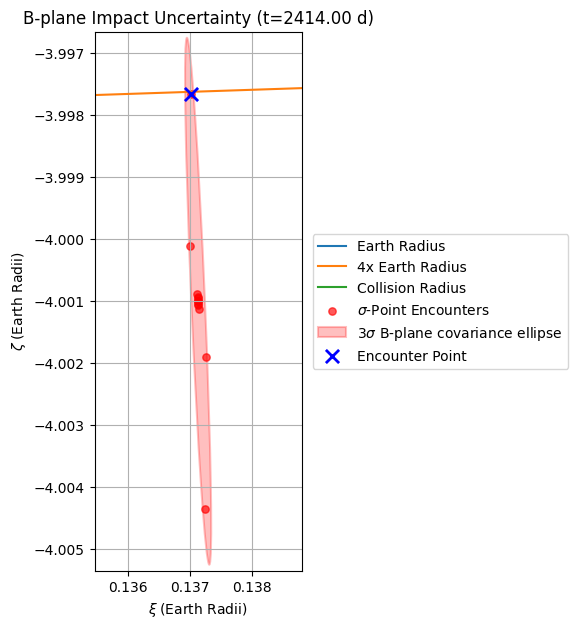

In [6]:
plot_bplane(xi=b_case["xi"], zeta=b_case["zeta"], b_coll=b_case["b_coll"], R=R_main, title=f"B-plane Impact Uncertainty (t={t_impulse:.2f} d)", include_uncertainty=True, uncertainty_cloud=b_cloud, zoom_uncertainty=True, zoom_pad=0.001)

Closest Valsecchi circles near the 4 R_E target ring:
300:299  ratio=1.003344  dist_to_4RE_ring=1.434283e-05 AU (2145.656 km)  dist_to_point=1.543491e-04 AU (23090.296 km)
299:298  ratio=1.003356  dist_to_4RE_ring=1.434726e-05 AU (2146.320 km)  dist_to_point=1.543494e-04 AU (23090.344 km)
298:297  ratio=1.003367  dist_to_4RE_ring=1.435173e-05 AU (2146.988 km)  dist_to_point=1.543497e-04 AU (23090.392 km)
297:296  ratio=1.003378  dist_to_4RE_ring=1.435623e-05 AU (2147.661 km)  dist_to_point=1.543501e-04 AU (23090.441 km)
296:295  ratio=1.003390  dist_to_4RE_ring=1.436075e-05 AU (2148.338 km)  dist_to_point=1.543504e-04 AU (23090.490 km)
295:294  ratio=1.003401  dist_to_4RE_ring=1.436531e-05 AU (2149.020 km)  dist_to_point=1.543507e-04 AU (23090.539 km)
294:293  ratio=1.003413  dist_to_4RE_ring=1.436990e-05 AU (2149.706 km)  dist_to_point=1.543511e-04 AU (23090.589 km)
293:292  ratio=1.003425  dist_to_4RE_ring=1.437452e-05 AU (2150.397 km)  dist_to_point=1.543514e-04 AU (23090.639 km)
29

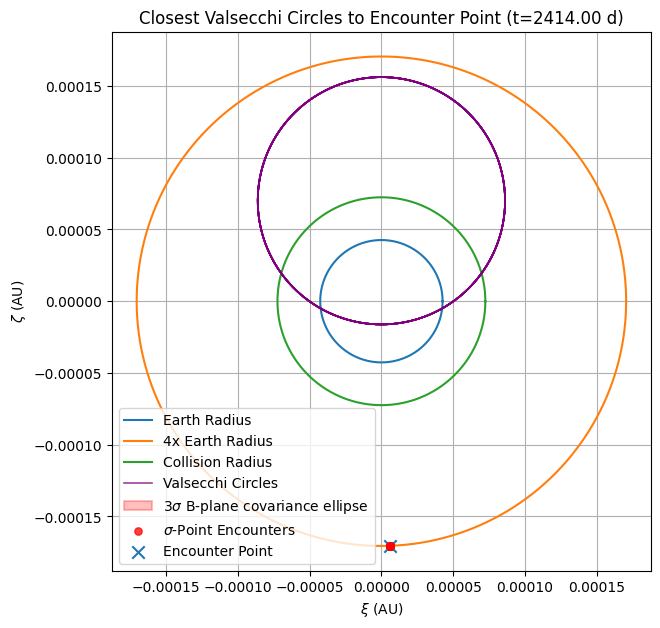

In [7]:
rE, vE, rA, vA = get_states_grss(b_case["sim"], b_case["t_sof_abs"], main_body_name="Earth")
xi_point = b_case["xi"]
zeta_point = b_case["zeta"]
closest, closest_circle_data, xi_v, zeta_v, b_coll_v, theta_v, phi_v = find_closest_valsecchi_circles(xi_point=xi_point, zeta_point=zeta_point, rE=rE, vE=vE, rA=rA, vA=vA, mu1=mu_sun, mu2=mu_main, R_planet=R_main, elements1=elements_main, units_in_km=False, max_p=300, top_n=12, R_asteroid=secondary_sol.get("radius", 0.0), ratio_min=1.0, ratio_max=5.0, target_b=4.0*R_main, target_b_tol=None)

print("Closest Valsecchi circles near the 4 R_E target ring:")
for c in closest:
    d_ring_au = c["distance_to_target_ring"]
    d_point_au = c["distance_to_circle"]
    print(
        f"{c['p']}:{c['q']}  "
        f"ratio={c['ratio']:.6f}  "
        f"dist_to_4RE_ring={d_ring_au:.6e} AU ({au2km(d_ring_au):.3f} km)  "
        f"dist_to_point={d_point_au:.6e} AU ({au2km(d_point_au):.3f} km)"
    )
plot_bplane_valsecchi(xi=xi_point, zeta=zeta_point, b_coll=b_case["b_coll"], R=R_main, circle_data=closest_circle_data, title=f"Closest Valsecchi Circles to Encounter Point (t={t_impulse:.2f} d)", units_in_km=False, include_uncertainty=True, uncertainty_cloud=b_cloud, uncertainty_scale=1.0)

**Radial Direction**

In [ ]:
dV_min, b_val, b_case = solve4accel2perturb_instantaneous_at_time_grss(
    sol_secondary=secondary_sol,      # asteroid GRSS solution dict
    cov_secondary=secondary_cov,      # asteroid covariance in GRSS order [e, q, tp, om, w, i]; use None for no covariance
    mu_main=mu_main,                  # Earth gravitational parameter [AU^3 / day^2]
    R_main=R_main,                    # Earth radius [AU]
    R_sof=R_main_sof,                 # sphere-of-influence radius used for encounter definition [AU]
    direction="radial",               # applied impulse direction
    b_target=b_main,                  # desired minimum b-plane miss distance [AU]
    t_impulse=t_impulse,              # impulse application time [days after epoch]
    t_max=t_max,                      # propagation horizon [days after epoch]
    dt=dt_search_imp,                 # time step used inside SOF/crossing searches [days]
    robust_metric="min_b",            # optimize against worst-case sigma-point b-plane miss distance
)
sign_label = "+" if dV_min >= 0 else "-"
print(f"--- Radial Impulse ---")
print(f"Sign: {sign_label}")
print(f"Relative Impulse Time: {t_impulse:.6f} d")
print(f"Minimum Required Impulse DeltaV: {au_per_day2km_per_s(abs(dV_min)):.6e} km/s")
print(f"Achieved Robust B-Plane Distance: {b_val:.6e} AU")
print(f"Worst-Case SOF Time: {b_case['t_sof_rel']:.6f} d")
print(f"Worst-Case xi: {b_case['xi']:.6e} AU")
print(f"Worst-Case zeta: {b_case['zeta']:.6e} AU")
print("")

--- Radial Impulse ---
Sign: -
Relative Impulse Time: 2239.000000 d
Minimum Required Impulse DeltaV: 1.129827e-03 km/s
Achieved Robust B-Plane Distance: 1.705416e-04 AU
Worst-Case SOF Time: 6110.431648 d
Worst-Case xi: 1.432364e-06 AU
Worst-Case zeta: -1.705356e-04 AU



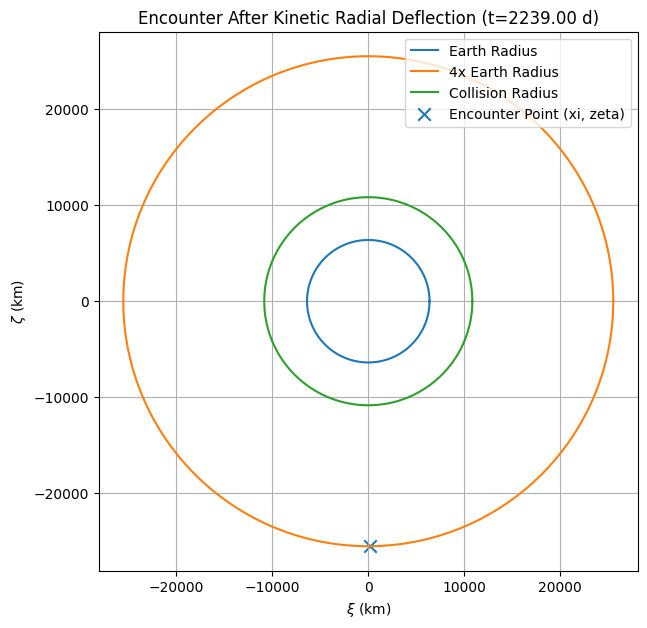

In [ ]:
plot_bplane(au2km(b_case["xi"]), au2km(b_case["zeta"]), au2km(b_case["b_coll"]), au2km(R_main), title=f"Encounter After Kinetic Radial Deflection (t={t_impulse:.2f} d)", units_in_km=True)

**Normal Direction**

In [5]:
dV_min, b_val, b_case = solve4accel2perturb_instantaneous_at_time_grss(
    sol_secondary=secondary_sol,      # asteroid GRSS solution dict
    cov_secondary=secondary_cov,      # asteroid covariance in GRSS order [e, q, tp, om, w, i]; use None for no covariance
    mu_main=mu_main,                  # Earth gravitational parameter [AU^3 / day^2]
    R_main=R_main,                    # Earth radius [AU]
    R_sof=R_main_sof,                 # sphere-of-influence radius used for encounter definition [AU]
    direction="normal",               # applied impulse direction
    b_target=b_main,                  # desired minimum b-plane miss distance [AU]
    t_impulse=t_impulse,              # impulse application time [days after epoch]
    t_max=t_max,                      # propagation horizon [days after epoch]
    dt=dt_search_imp,                 # time step used inside SOF/crossing searches [days]
    robust_metric="min_b",            # optimize against worst-case sigma-point b-plane miss distance
)
sign_label = "+" if dV_min >= 0 else "-"
print(f"--- Normal Impulse ---")
print(f"Sign: {sign_label}")
print(f"Relative Impulse Time: {t_impulse:.6f} d")
print(f"Minimum Required Impulse DeltaV: {au_per_day2km_per_s(abs(dV_min)):.6e} km/s")
print(f"Achieved Robust B-Plane Distance: {b_val:.6e} AU")
print(f"Worst-Case SOF Time: {b_case['t_sof_rel']:.6f} d")
print(f"Worst-Case xi: {b_case['xi']:.6e} AU")
print(f"Worst-Case zeta: {b_case['zeta']:.6e} AU")
print("")

--- Normal Impulse ---
Sign: +
Relative Impulse Time: 2239.000000 d
Minimum Required Impulse DeltaV: 2.992378e-02 km/s
Achieved Robust B-Plane Distance: 1.705416e-04 AU
Worst-Case SOF Time: 6110.423979 d
Worst-Case xi: 5.928468e-06 AU
Worst-Case zeta: -1.704386e-04 AU



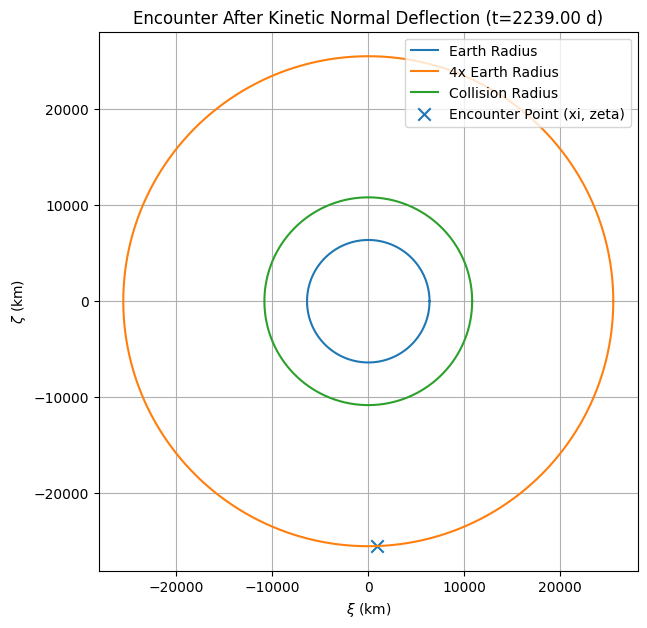

In [ ]:
plot_bplane(au2km(b_case["xi"]), au2km(b_case["zeta"]), au2km(b_case["b_coll"]), au2km(R_main), title=f"Encounter After Kinetic Normal Deflection (t={t_impulse:.2f} d)", units_in_km=True)